In [1]:
import os
from dotenv import set_key
dotenv_path = os.path.join('.env')
set_key(dotenv_path, "API_URL", "https://data-charts-api.hexlet.app")
set_key(dotenv_path, "DATE_BEGIN", "2023-03-01")
set_key(dotenv_path, "DATE_END", "2023-09-01")

os.chmod(dotenv_path, 0o644)

In [3]:
import requests as rq
import pandas as pd
from dotenv import load_dotenv

load_dotenv()

DATE_BEGIN = os.getenv('DATE_BEGIN')
DATE_END = os.getenv('DATE_END')
API_URL = os.getenv('API_URL')

# получение данных
test = rq.get(f'{API_URL}/visits', params={'begin':DATE_BEGIN, 'end':DATE_END})
test2 = rq.get(f'{API_URL}/registrations', params={'begin':DATE_BEGIN, 'end':DATE_END})
visits = test.json()
regs = test2.json()
# формирование датафреймов
visit = pd.DataFrame(visits)
reg = pd.DataFrame(regs)
# фильтрация последних визитов
visit['last_visit'] = visit.groupby('visit_id')['datetime'].transform("max")
visit = visit[visit['datetime'] == visit['last_visit']]
# приведение даты визитов к образцу, чистка данных
visit = visit[(visit['user_agent'] != 'bot') & (visit['platform'] != 'bot')]
visit['datetime'] = pd.to_datetime(visit['datetime'])
visit['datetime'] = visit['datetime'].dt.floor("D")
# удаление ненужных столбцов, группировка и подсчет визитов
df1 = visit.drop(['user_agent'], axis = 1).groupby(['datetime', 'platform'])['visit_id'].count().rename('visits')
# приведение даты регистраций к образцу
reg['datetime'] = pd.to_datetime(reg['datetime']).dt.floor("D")
# удаление ненужных столбцов и подсчет регистраций
df2 = reg.drop(['registration_type', 'email'], axis = 1).groupby(['datetime', 'platform'])['user_id'].count().rename('registrations')
# объединение столбцов
aggr = pd.concat([df1,df2], axis = 1).fillna(0)
aggr['registrations'] = aggr['registrations'].astype(int)
# добавление конверсии
aggr['conversion'] = aggr['registrations']/aggr['visits']*100
aggr = aggr.reset_index()
aggr = aggr.rename(columns={"datetime": "date_group"})
aggr.to_json('./conversion.json')
aggr

C:\Users\anaconda\AppData\Local\Temp\ipykernel_15344\1845489218.py:39: Pandas4Warning: The default 'epoch' date format is deprecated and will be removed in a future version, please use 'iso' date format instead.
  aggr.to_json('./conversion.json')


,date_group,platform,visits,registrations,conversion
0,2023-03-01,android,75,61,81.333333
1,2023-03-01,ios,22,18,81.818182
2,2023-03-01,web,279,8,2.867384
3,2023-03-02,android,67,59,88.059701
4,2023-03-02,ios,31,24,77.419355
...,...,...,...,...,...
547,2023-08-30,ios,66,40,60.606061
548,2023-08-30,web,1227,34,2.770986
549,2023-08-31,android,57,42,73.684211
550,2023-08-31,ios,50,36,72.000000


In [11]:
import os
import requests as rq
import pandas as pd
from dotenv import load_dotenv

load_dotenv(r"C:\Users\anaconda\Project\.env")

DATE_BEGIN = os.getenv('DATE_BEGIN')
DATE_END = os.getenv('DATE_END')
API_URL = os.getenv('API_URL')

# получение данных
test = rq.get(f'{API_URL}/visits', params={'begin': DATE_BEGIN, 'end': DATE_END})
test2 = rq.get(f'{API_URL}/registrations', params={'begin': DATE_BEGIN, 'end': DATE_END})
visits = test.json()
regs = test2.json()

# формирование датафреймов
visit = pd.DataFrame(visits)
visit = visit.rename(columns={"datetime": "date_group"})
reg = pd.DataFrame(regs)
reg = reg.rename(columns={"datetime": "date_group"})
# фильтрация последних визитов
visit['last_visit'] = visit.groupby('visit_id')['date_group'].transform("max")
visit = visit[visit['date_group'] == visit['last_visit']]

# приведение даты визитов к образцу, чистка данных
visit = visit[(visit['user_agent'] != 'bot') & (visit['platform'] != 'bot')]
visit['date_group'] = pd.to_datetime(visit['date_group'])
visit['date_group'] = visit['date_group'].dt.floor("D")

# удаление ненужных столбцов, группировка и подсчет визитов
df1 = visit.drop(['user_agent', 'platform'], axis=1).groupby(['date_group'])['visit_id'].count().rename('visits')

# приведение даты регистраций к образцу
reg['date_group'] = pd.to_datetime(reg['date_group']).dt.floor("D")

# удаление ненужных столбцов и подсчет регистраций
df2 = reg.drop(['registration_type', 'email', 'platform'], axis=1).groupby(['date_group'])['user_id'].count().rename('registrations')

# объединение столбцов
aggr = pd.concat([df1, df2], axis=1).fillna(0)
aggr['registrations'] = aggr['registrations'].astype(int)

# добавление рекламы
ad = pd.read_csv('./ads.csv', header=0)
ad['date_group'] = pd.to_datetime(ad['date'])
ad['date_group'] = ad['date_group'].dt.floor('D')
ads = ad.drop(['utm_source', 'utm_medium'], axis=1).groupby(['date_group', 'utm_campaign'])['cost'].sum().rename('cost')
ads = pd.DataFrame(ads)
ads = ads.reset_index().set_index('date_group')
with_ads = pd.concat([aggr, ads], axis=1).fillna('none')
with_ads.to_json('./ads.json')
with_ads

,visits,registrations,utm_campaign,cost
date_group,,,,
2023-03-01,376.0,87.0,advanced_algorithms_series,212.0
2023-03-02,613.0,106.0,advanced_algorithms_series,252.0
2023-03-03,683.0,107.0,advanced_algorithms_series,202.0
2023-03-04,647.0,159.0,advanced_algorithms_series,223.0
2023-03-05,707.0,115.0,advanced_algorithms_series,265.0
...,...,...,...,...
2023-09-13,none,none,intro_to_python_course,277.0
2023-09-14,none,none,intro_to_python_course,221.0
2023-09-15,none,none,intro_to_python_course,175.0


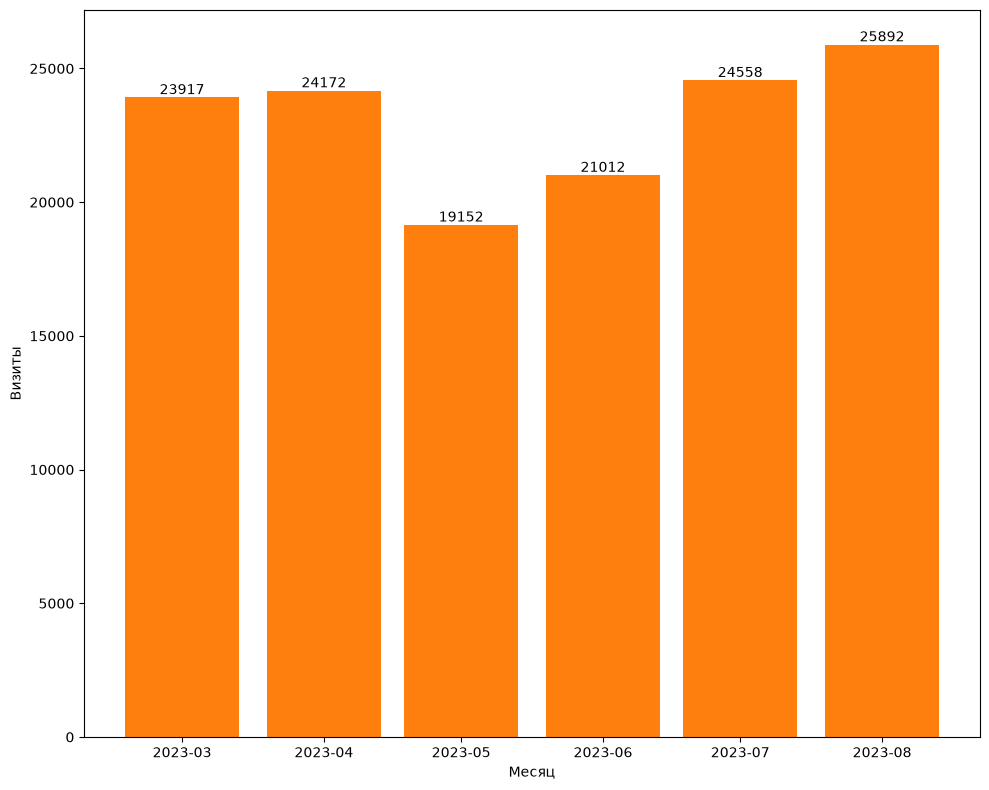

In [24]:
#итоговые визиты
import requests as rq
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

reading_file = pd.read_json('./conversion.json')
plots = pd.DataFrame(reading_file)
plots['date_group'] = pd.to_datetime(plots['date_group'], unit='ms')
daily = plots.copy()
daily['month'] = plots['date_group'].dt.to_period('M').dt.start_time
daily = daily.groupby('month', as_index=False)['visits'].sum()
daily = daily.sort_values('month')

fig, ax = plt.subplots(figsize=(10, 8))
ax.bar(daily['month'], daily['visits'], width=20)
bars = ax.bar(daily['month'], daily['visits'], width=25)
ax.bar_label(bars)
ax.set_xlabel('Месяц')
ax.set_ylabel('Визиты')
plt.tight_layout()
plt.savefig('./visits.png')
plt.show()

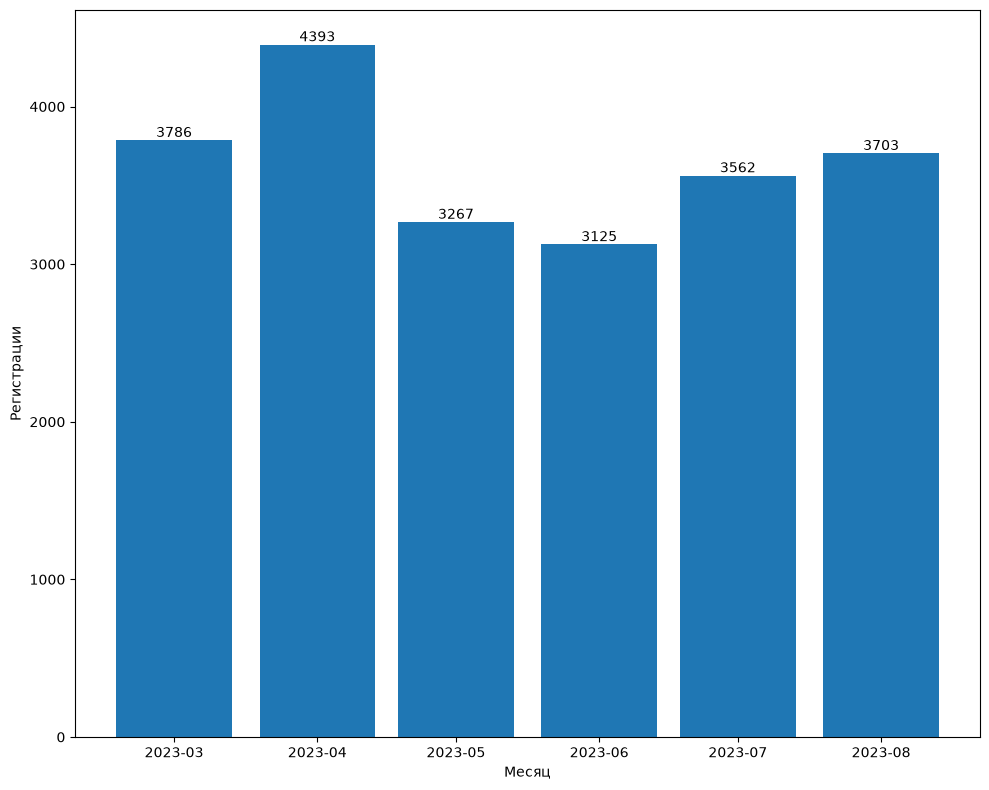

In [26]:
# итоговые регистрации
import requests as rq
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

reading_file = pd.read_json('./conversion.json')
plots = pd.DataFrame(reading_file)
plots['date_group'] = pd.to_datetime(plots['date_group'], unit='ms')  
daily = plots.copy()
daily['month'] = plots['date_group'].dt.to_period('M').dt.start_time
daily = daily.groupby('month', as_index=False)['registrations'].sum()
daily = daily.sort_values('month')

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.bar(daily['month'], daily['registrations'], width=25)
ax.bar_label(bars)
ax.set_xlabel('Месяц')
ax.set_ylabel('Регистрации')
plt.tight_layout()
plt.savefig('./charts/registrations.png')
plt.show()

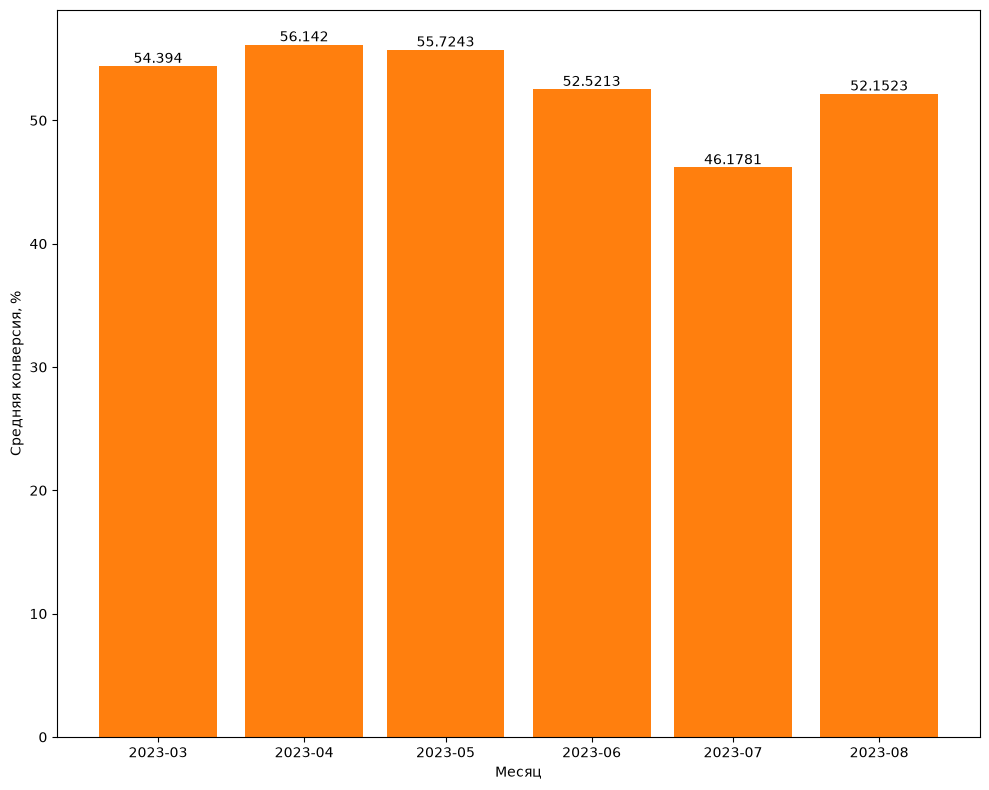

In [45]:
#итоговые конверсии
import requests as rq
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

reading_file = pd.read_json('./conversion.json')
plots = pd.DataFrame(reading_file)
plots['date_group'] = pd.to_datetime(plots['date_group'], unit='ms')
daily = plots.copy()
daily['month'] = plots['date_group'].dt.to_period('M').dt.start_time
daily = daily.groupby('month', as_index=False)['conversion'].mean()
daily = daily.sort_values('month')

fig, ax = plt.subplots(figsize=(10, 8))
ax.bar(daily['month'], daily['conversion'], width=20)
bars = ax.bar(daily['month'], daily['conversion'], width=25)
ax.bar_label(bars)
ax.set_xlabel('Месяц')
ax.set_ylabel('Средняя конверсия, %')
plt.tight_layout()
plt.savefig('./charts/conversion.png')
plt.show()

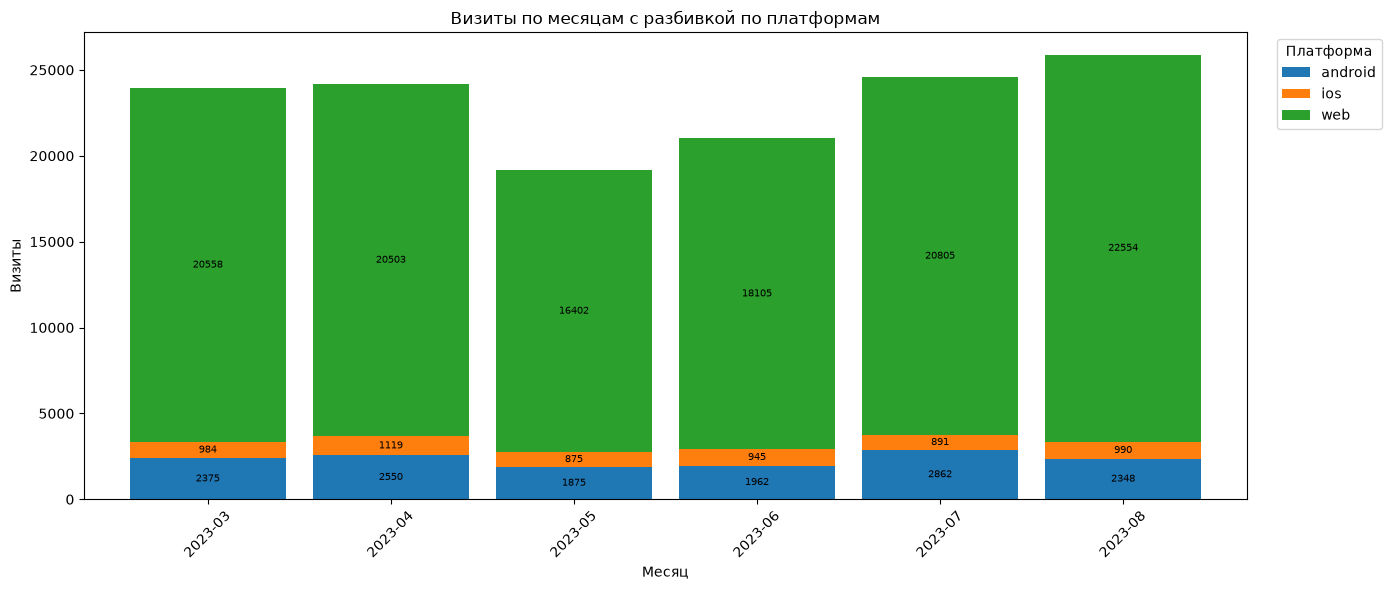

In [50]:
#визиты по месяцам с разбивкой на платформы
import pandas as pd
import matplotlib.pyplot as plt

reading_file = pd.read_json('./conversion.json')
plots = pd.DataFrame(reading_file)
plots['date_group'] = pd.to_datetime(plots['date_group'], unit='ms')

daily = plots.copy()
daily['month'] = daily['date_group'].dt.to_period('M')

daily = daily.groupby(['month', 'platform'], as_index=False)['visits'].sum()
daily = daily.sort_values('month')
pivot = daily.pivot(index='month', columns='platform', values='visits').fillna(0)

fig, ax = plt.subplots(figsize=(14, 6))
pivot.plot(kind='bar', stacked=True, ax=ax, width=0.85)
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', fontsize=7, label_type='center')
ax.set_xticklabels([str(p) for p in pivot.index], rotation=45)
ax.set_title('Визиты по месяцам с разбивкой по платформам')
ax.set_xlabel('Месяц')
ax.set_ylabel('Визиты')
ax.legend(title='Платформа', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('./charts/visits_by_month_platform.png')
plt.show()

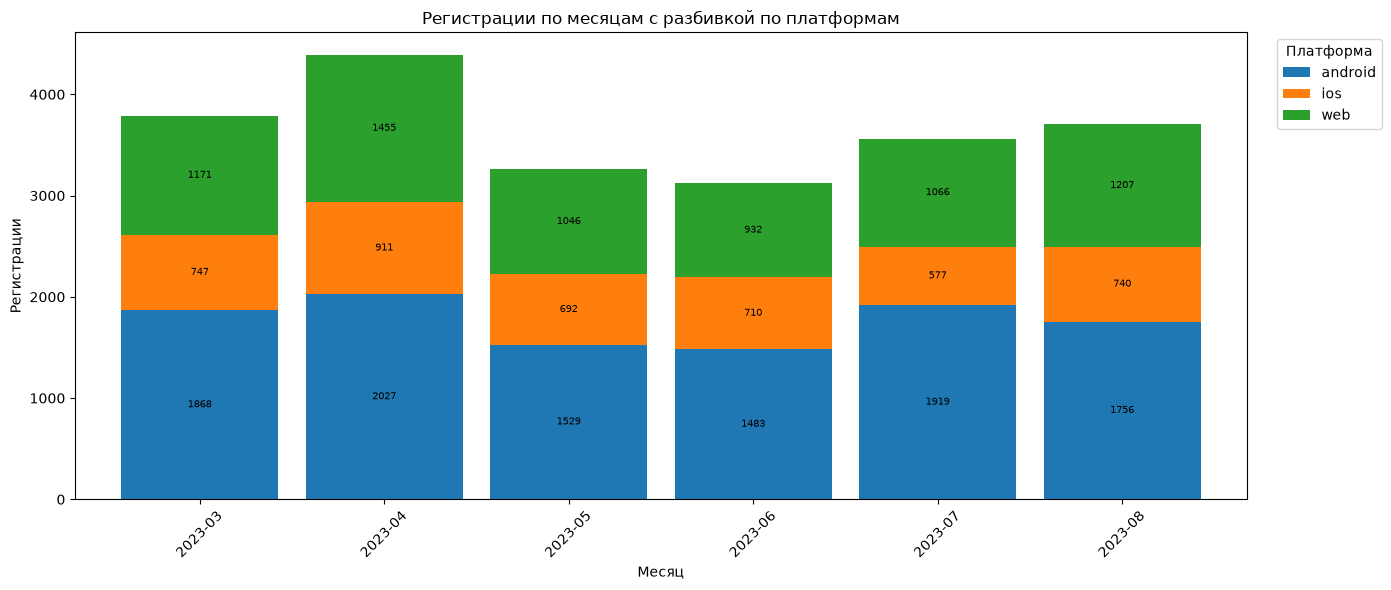

In [54]:
# регистрации по месяцам с разбивкой на платформы
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

reading_file = pd.read_json('./conversion.json')
plots = pd.DataFrame(reading_file)

plots['date_group'] = pd.to_datetime(plots['date_group'], errors='coerce', unit='ms')
daily = plots.copy()
daily['month'] = daily['date_group'].dt.strftime('%Y-%m') 

daily = daily.groupby(['month', 'platform'], as_index=False)['registrations'].sum()
daily = daily.sort_values('month')
pivot = daily.pivot(index='month', columns='platform', values='registrations').fillna(0)

fig, ax = plt.subplots(figsize=(14, 6))
pivot.plot(kind='bar', stacked=True, ax=ax, width=0.85)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', fontsize=7, label_type='center')

ax.set_xticklabels(pivot.index, rotation=45)   # уже готовые строки 'YYYY-MM'

ax.set_title('Регистрации по месяцам с разбивкой по платформам')
ax.set_xlabel('Месяц')
ax.set_ylabel('Регистрации')
ax.legend(title='Платформа', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('./charts/registrations_by_month_platform.png')
plt.show()

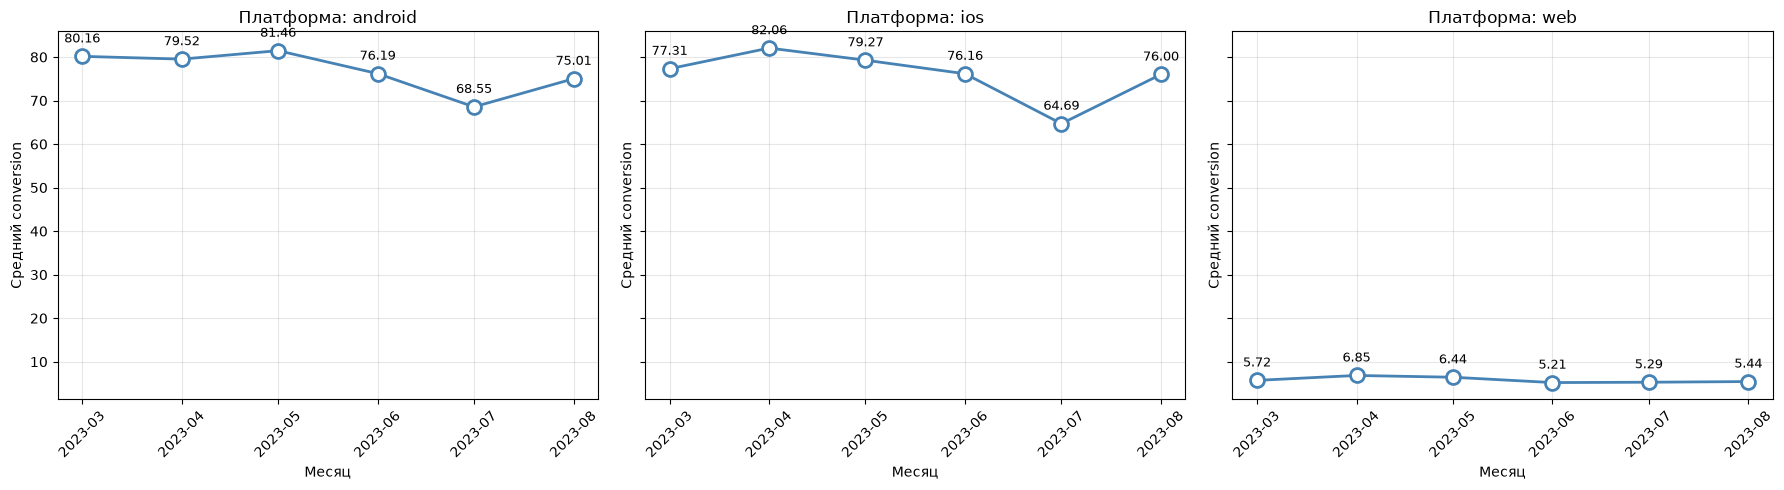

In [57]:
import pandas as pd
import matplotlib.pyplot as plt

plots = pd.read_json('./conversion.json')

plots['date_group'] = pd.to_datetime(plots['date_group'], unit='ms')
plots['conversion'] = pd.to_numeric(plots['conversion'], errors='coerce')
plots['month'] = plots['date_group'].dt.to_period('M').dt.start_time

daily = (plots.groupby(['month', 'platform'], as_index=False)['conversion']
              .mean()
              .sort_values('month'))

platforms = daily['platform'].unique()

fig, axes = plt.subplots(1, len(platforms), figsize=(6 * len(platforms), 5), sharey=True)

# если платформа одна — axes не список, приводим к списку
if len(platforms) == 1:
    axes = [axes]

for ax, platform in zip(axes, platforms):
    sub = daily[daily['platform'] == platform].sort_values('month')

    ax.plot(sub['month'], sub['conversion'],
            marker='o', markersize=10, linewidth=2,
            color='steelblue', markerfacecolor='white',
            markeredgewidth=2, markeredgecolor='steelblue')

    # подписи значений над точками
    for x, y in zip(sub['month'], sub['conversion']):
        ax.annotate(f'{y:.2f}',
                    xy=(x, y),
                    xytext=(0, 10),
                    textcoords='offset points',
                    ha='center',
                    fontsize=9)

    ax.set_title(f'Платформа: {platform}', fontsize=12)
    ax.set_xlabel('Месяц')
    ax.set_ylabel('Средний conversion')
    ax.grid(True, alpha=0.3)

    ax.set_xticks(sub['month'])
    ax.set_xticklabels([d.strftime('%Y-%m') for d in sub['month']], rotation=45)

plt.tight_layout()
plt.savefig('./charts/conversion_by_platform.png')
plt.show()

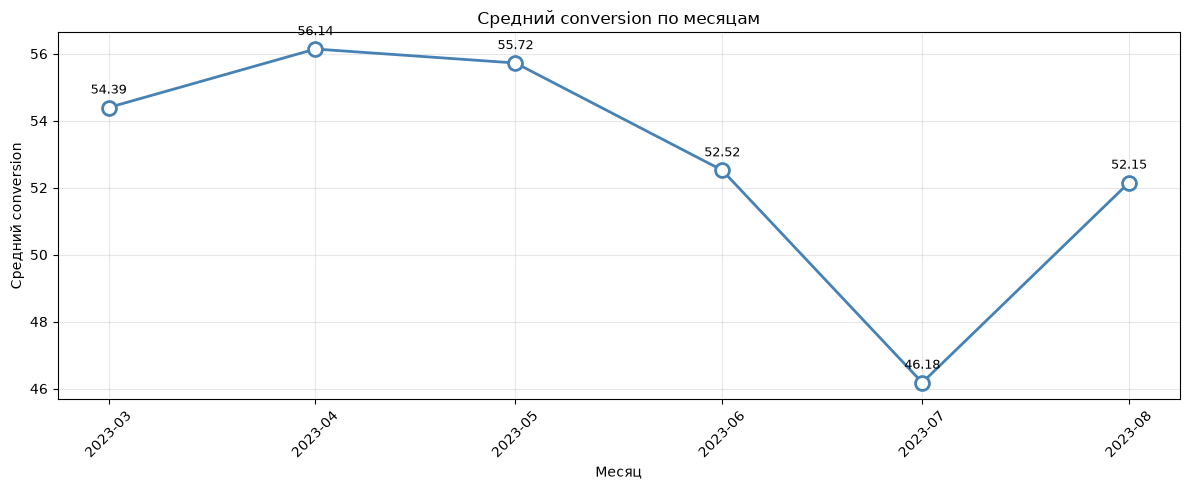

In [60]:
import pandas as pd
import matplotlib.pyplot as plt

plots = pd.read_json('./conversion.json')

plots['date_group'] = pd.to_datetime(plots['date_group'], unit='ms')
plots['conversion'] = pd.to_numeric(plots['conversion'], errors='coerce')
plots['month'] = plots['date_group'].dt.to_period('M').dt.start_time

# Средний conversion по месяцам (по всем платформам вместе)
daily = (plots.groupby('month', as_index=False)['conversion']
              .mean()
              .sort_values('month'))

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(daily['month'], daily['conversion'],
        marker='o', markersize=10, linewidth=2,
        color='steelblue', markerfacecolor='white',
        markeredgewidth=2, markeredgecolor='steelblue')

# Подписи значений над точками
for x, y in zip(daily['month'], daily['conversion']):
    ax.annotate(f'{y:.2f}',
                xy=(x, y),
                xytext=(0, 10),
                textcoords='offset points',
                ha='center',
                fontsize=9)

ax.set_title('Средний conversion по месяцам')
ax.set_xlabel('Месяц')
ax.set_ylabel('Средний conversion')
ax.grid(True, alpha=0.3)

ax.set_xticks(daily['month'])
ax.set_xticklabels([d.strftime('%Y-%m') for d in daily['month']], rotation=45)

plt.tight_layout()
plt.savefig('./charts/conversion_by_month.png')
plt.show()

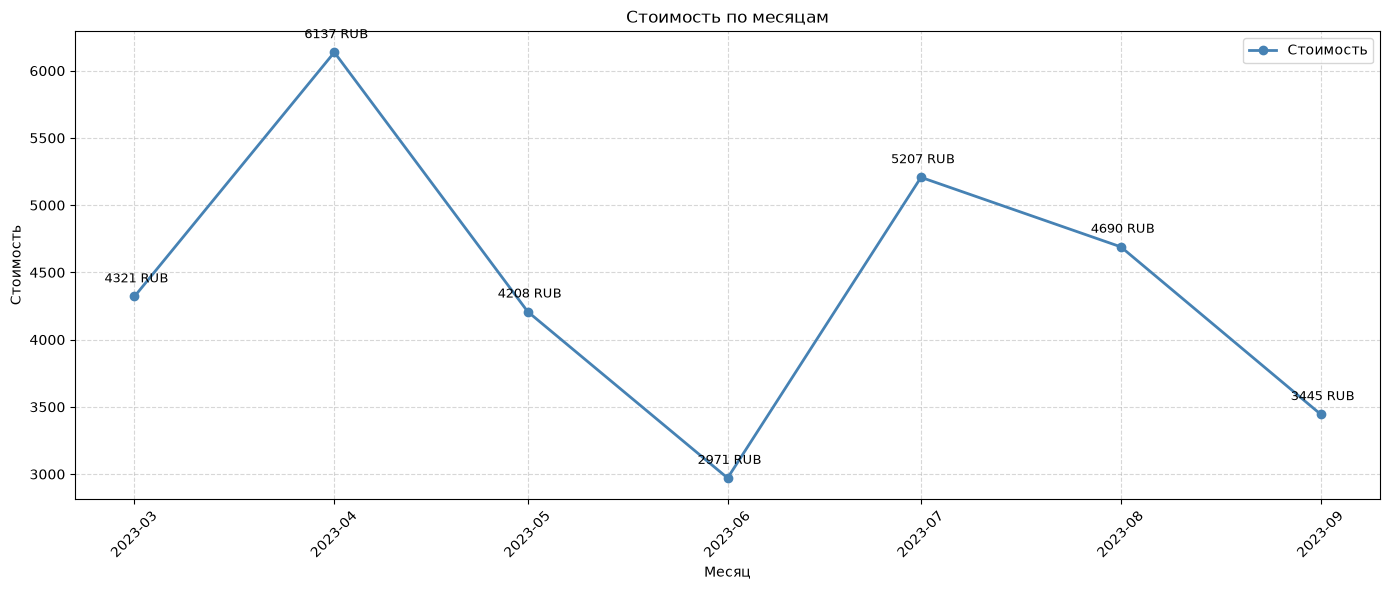

In [61]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Читаем JSON
upload_data = pd.read_json('./ads.json')

# 2. Индекс (даты) делаем столбцом 'date'
upload_data = upload_data.reset_index().rename(columns={'index': 'date'})

# 3. Убираем мусорные строки-заголовки, если они есть
upload_data = upload_data[~upload_data['date'].isin(['date', 'month', 'cost'])]

# 4. Приводим типы
upload_data['date'] = pd.to_datetime(upload_data['date'], errors='coerce')
upload_data = upload_data.dropna(subset=['date'])
upload_data['cost'] = pd.to_numeric(upload_data['cost'], errors='coerce').fillna(0)

# 5. Столбец 'month' — начало месяца
upload_data['month'] = upload_data['date'].dt.to_period('M').dt.start_time

# 6. Группировка по месяцам
monthly = upload_data.groupby('month', as_index=False)['cost'].sum()

# 7. График с подписями
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(monthly['month'], monthly['cost'],
        marker='o', linewidth=2, color='steelblue', label='Стоимость')

# --- Подписи значений над точками ---
for x, y in zip(monthly['month'], monthly['cost']):
    ax.annotate(f'{y: .0f} RUB',                 # формат числа: 12,345
                xy=(x, y),                   # координата точки
                xytext=(0, 8),               # сдвиг текста вверх на 8 пунктов
                textcoords='offset points',
                ha='center', va='bottom',
                fontsize=9, color='black')

ax.set_xlabel('Месяц')
ax.set_ylabel('Стоимость')
ax.set_title('Стоимость по месяцам')
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('./charts/cost_by_month.png')
plt.show()

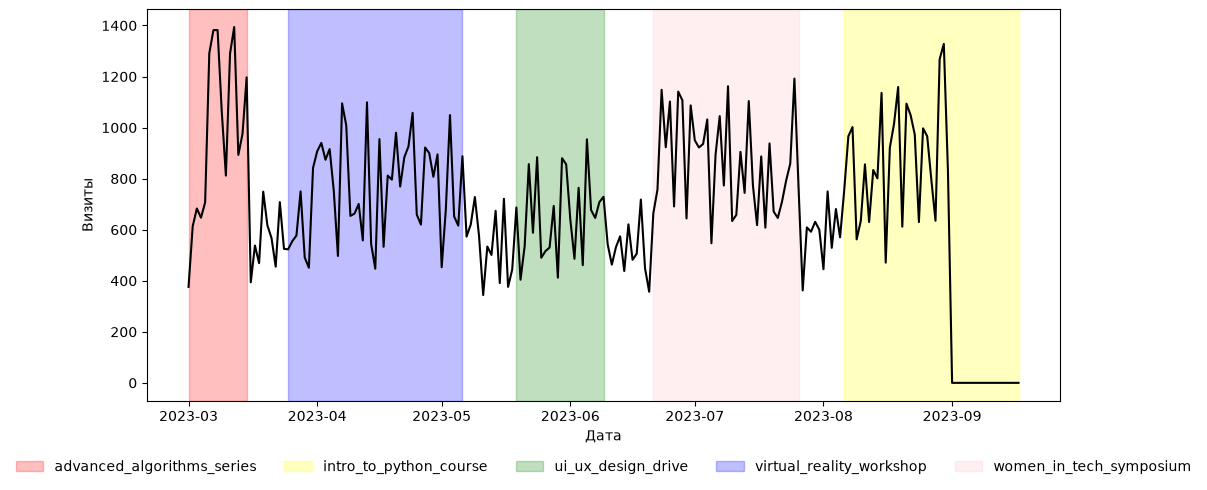

In [62]:
import pandas as pd
import matplotlib.pyplot as plt

# ---- 1. загрузка ----
data = pd.read_json('./ads.json')
data_plot = pd.DataFrame(data).reset_index()
data_plot['index'] = pd.to_datetime(data_plot['index'])

# ---- 2. подготовка ----
data_plot1 = data_plot.drop(['registrations', 'cost'], axis=1)
data_plot1['visits'] = data_plot1['visits'].replace('none', 0)
data_plot1['visits'] = pd.to_numeric(data_plot1['visits'])

# ---- 3. цвета ----
colors = {
    'advanced_algorithms_series': 'red',
    'virtual_reality_workshop': 'blue',
    'ui_ux_design_drive': 'green',
    'women_in_tech_symposium': 'pink',
    'intro_to_python_course': 'yellow',
}

# ---- 4. график ----
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(data_plot1['index'], data_plot1['visits'],
        color='black', linewidth=1.5)

for campaign, group in data_plot1.groupby('utm_campaign'):
    if campaign not in colors:
        continue
    ax.axvspan(group['index'].min(), group['index'].max(),
               color=colors[campaign], alpha=0.25, zorder=0,
               label=campaign)

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12),
          ncol=5, frameon=False)
ax.set_xlabel('Дата')
ax.set_ylabel('Визиты')
plt.tight_layout()
plt.savefig('./charts/visits_campaigns.png')
plt.show()

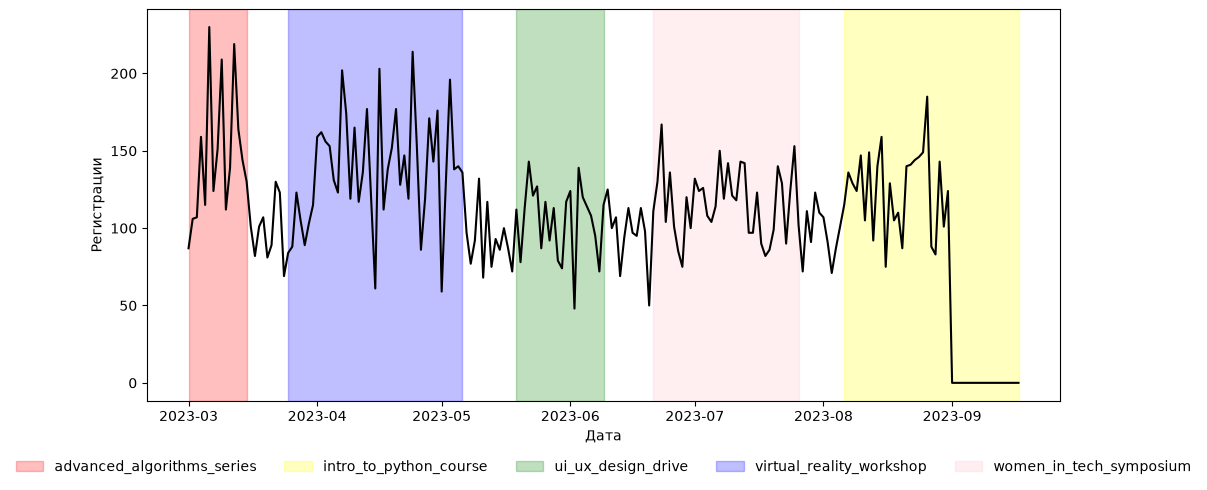

In [63]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_json('./ads.json')
data_plot = pd.DataFrame(data).reset_index()
data_plot['index'] = pd.to_datetime(data_plot['index'])

data_plot1 = data_plot.drop(['visits', 'cost'], axis=1)
data_plot1['registrations'] = data_plot1['registrations'].replace('none', 0)
data_plot1['registrations'] = pd.to_numeric(data_plot1['registrations'])

# ---- 3. цвета ----
colors = {
    'advanced_algorithms_series': 'red',
    'virtual_reality_workshop': 'blue',
    'ui_ux_design_drive': 'green',
    'women_in_tech_symposium': 'pink',
    'intro_to_python_course': 'yellow',
}

# ---- 4. график ----
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(data_plot1['index'], data_plot1['registrations'],
        color='black', linewidth=1.5)

for campaign, group in data_plot1.groupby('utm_campaign'):
    if campaign not in colors:
        continue
    ax.axvspan(group['index'].min(), group['index'].max(),
               color=colors[campaign], alpha=0.25, zorder=0,
               label=campaign)

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12),
          ncol=5, frameon=False)
ax.set_xlabel('Дата')
ax.set_ylabel('Регистрации')
plt.tight_layout()
plt.savefig('./charts/regs_campaigns.png')
plt.show()